# Multivariate Model Progression Table

This notebook builds a model progression table from every file in `/edata/obdw/sandwich_analysis_data` ending with `analysis_wer_coeftest.csv`.

Outputs created by the notebook:
- `multivariate_model_progression_table.csv`: presentation table with one row per variable
- `multivariate_model_progression_table_full.csv`: same table including `(Intercept)` and `pid`
- `multivariate_model_progression_counts_detail.csv`: model-specific count details
- `multivariate_model_progression_long_detail.csv`: long-form coefficient detail

Count handling:
- The main `Count` column is the maximum available count observed for that variable across the included models.
- Model-specific counts are also saved separately so you can inspect differences across models.

In [10]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

sys.path.insert(0, '/home/NETID/emd5')
from avh_utils import decode_variable_name

DATA_DIR = Path('/edata/obdw/sandwich_analysis_data')
MODEL_FILES = sorted(DATA_DIR.glob('*analysis_wer_coeftest.csv'))

if not MODEL_FILES:
    raise FileNotFoundError('No files ending with analysis_wer_coeftest.csv were found in /edata/obdw/sandwich_analysis_data')

print('Models included:')
for model_file in MODEL_FILES:
    print(f'  - {model_file.name}')

Models included:
  - basic_analysis_wer_coeftest.csv
  - basic_plus_analysis_wer_coeftest.csv
  - basic_plus_clinical_analysis_wer_coeftest.csv
  - basic_plus_clinical_sdh_analysis_wer_coeftest.csv
  - location_encoded_analysis_wer_coeftest.csv
  - location_stratified_analysis_wer_coeftest.csv


In [11]:
def standardize_coeftest_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {
        'Std. Error': 'Std_Error',
        'Std..Error': 'Std_Error',
        'Pr(>|t|)': 'p_value',
        'p.value': 'p_value',
        't value': 't_value',
        't.value': 't_value',
    }
    out = df.rename(columns={old: new for old, new in rename_map.items() if old in df.columns}).copy()
    if 'Variable' not in out.columns:
        out['Variable'] = out.index.astype(str)
    return out


def significance_stars(p_value):
    if pd.isna(p_value):
        return ''
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return ''


def format_model_cell(estimate, p_value):
    if pd.isna(estimate):
        return '—'
    return f'{estimate:.3f}{significance_stars(p_value)}'


def parse_numeric_token(token):
    try:
        return float(token)
    except (TypeError, ValueError):
        return None


def compute_variable_count(term: str, analysis_df: pd.DataFrame | None):
    if analysis_df is None:
        return pd.NA

    term = str(term).strip().strip('\"')
    if term in {'(Intercept)', 'pid'}:
        return pd.NA

    if term in analysis_df.columns:
        series = analysis_df[term]
        values = set(series.dropna().unique().tolist())
        if values and values.issubset({0, 1, 0.0, 1.0, True, False}):
            return int((series == 1).sum())
        return int(series.notna().sum())

    parts = term.split('_')
    if len(parts) >= 2:
        base_name = '_'.join(parts[:-1])
        category_value = parse_numeric_token(parts[-1])
        if category_value is not None and base_name in analysis_df.columns:
            numeric_series = pd.to_numeric(analysis_df[base_name], errors='coerce')
            return int((numeric_series == category_value).sum())

    return pd.NA


def build_progression_outputs(model_files):
    records = []

    for model_path in model_files:
        coeftest_df = pd.read_csv(model_path, index_col=0)
        coeftest_df = standardize_coeftest_columns(coeftest_df)

        analysis_data_path = DATA_DIR / model_path.name.replace('_wer_coeftest.csv', '.csv')
        analysis_df = pd.read_csv(analysis_data_path, index_col=0) if analysis_data_path.exists() else None

        for _, row in coeftest_df.iterrows():
            variable_raw = str(row['Variable'])
            records.append({
                'Variable_Raw': variable_raw,
                'Variable': decode_variable_name(variable_raw),
                'Model': model_path.name,
                'Estimate': row.get('Estimate', pd.NA),
                'p_value': row.get('p_value', pd.NA),
                'Formatted': format_model_cell(row.get('Estimate', pd.NA), row.get('p_value', pd.NA)),
                'Count_ModelSpecific': compute_variable_count(variable_raw, analysis_df),
                'Source_Data_File': analysis_data_path.name if analysis_data_path.exists() else pd.NA,
            })

    long_detail = pd.DataFrame(records)

    count_detail = (
        long_detail
        .pivot(index=['Variable_Raw', 'Variable'], columns='Model', values='Count_ModelSpecific')
        .reset_index()
    )

    model_columns = [model_path.name for model_path in model_files]
    count_detail.columns.name = None

    def summarize_counts(row):
        values = [row[col] for col in model_columns if col in row.index and pd.notna(row[col])]
        if not values:
            return pd.Series({'Count': pd.NA, 'Count_Min': pd.NA, 'Count_Max': pd.NA, 'Models_With_Count': 0})
        values = [int(v) for v in values]
        return pd.Series({
            'Count': max(values),
            'Count_Min': min(values),
            'Count_Max': max(values),
            'Models_With_Count': len(values),
        })

    count_summary = count_detail.apply(summarize_counts, axis=1)
    count_detail = pd.concat([count_detail, count_summary], axis=1)

    progression_matrix = (
        long_detail
        .pivot(index='Variable_Raw', columns='Model', values='Formatted')
        .reindex(columns=model_columns)
    )

    variable_lookup = long_detail[['Variable_Raw', 'Variable']].drop_duplicates().set_index('Variable_Raw')
    count_lookup = count_detail.set_index('Variable_Raw')[['Count', 'Count_Min', 'Count_Max', 'Models_With_Count']]

    progression_table_full = variable_lookup.join(count_lookup).join(progression_matrix)
    progression_table_full = progression_table_full.reset_index()
    progression_table_full = progression_table_full[['Count', 'Variable', 'Variable_Raw'] + model_columns + ['Count_Min', 'Count_Max', 'Models_With_Count']]
    progression_table_full[model_columns] = progression_table_full[model_columns].fillna('—')
    progression_table_full = progression_table_full.sort_values(['Count', 'Variable', 'Variable_Raw'], ascending=[False, True, True], na_position='last').reset_index(drop=True)

    progression_table = progression_table_full[~progression_table_full['Variable_Raw'].isin(['(Intercept)', 'pid'])].reset_index(drop=True)

    return progression_table, progression_table_full, count_detail, long_detail

In [12]:
progression_table, progression_table_full, count_detail, long_detail = build_progression_outputs(MODEL_FILES)

presentation_output = DATA_DIR / 'multivariate_model_progression_table.csv'
full_output = DATA_DIR / 'multivariate_model_progression_table_full.csv'
counts_output = DATA_DIR / 'multivariate_model_progression_counts_detail.csv'
long_output = DATA_DIR / 'multivariate_model_progression_long_detail.csv'

progression_table.to_csv(presentation_output, index=False)
progression_table_full.to_csv(full_output, index=False)
count_detail.to_csv(counts_output, index=False)
long_detail.to_csv(long_output, index=False)

print(f'Saved presentation table to: {presentation_output}')
print(f'Saved full table to: {full_output}')
print(f'Saved count detail to: {counts_output}')
print(f'Saved long detail to: {long_output}')
print()
print(f'Presentation table shape: {progression_table.shape}')
print(f'Full table shape: {progression_table_full.shape}')

display(progression_table)

Saved presentation table to: /edata/obdw/sandwich_analysis_data/multivariate_model_progression_table.csv
Saved full table to: /edata/obdw/sandwich_analysis_data/multivariate_model_progression_table_full.csv
Saved count detail to: /edata/obdw/sandwich_analysis_data/multivariate_model_progression_counts_detail.csv
Saved long detail to: /edata/obdw/sandwich_analysis_data/multivariate_model_progression_long_detail.csv

Presentation table shape: (87, 12)
Full table shape: (89, 12)


,Count,Variable,Variable_Raw,basic_analysis_wer_coeftest.csv,basic_plus_analysis_wer_coeftest.csv,basic_plus_clinical_analysis_wer_coeftest.csv,basic_plus_clinical_sdh_analysis_wer_coeftest.csv,location_encoded_analysis_wer_coeftest.csv,location_stratified_analysis_wer_coeftest.csv,Count_Min,Count_Max,Models_With_Count
0,2859,AMOS,AMOS,-0.187***,0.382***,0.348***,0.318***,0.234**,-0.115***,2859,2859,4
1,2859,Pause Proportion,pause_proportion,—,0.181,0.205,0.088,0.133,0.313,2859,2859,3
2,2859,Predicted Mean Opinion Score (MOS),pred_mos,—,-0.572***,-0.550***,-0.511***,-0.386***,—,2859,2859,3
3,2686,Serious Mental Illness (SMI) Diagnosis,dx_group_smi,—,—,0.145,0.121,0.121,0.118,2686,2686,2
4,2664,SCL-9 Moderate Distress (≥1.0),SCL9_moderate,—,—,-0.167,-0.253,-0.236,—,2664,2664,2
...,...,...,...,...,...,...,...,...,...,...,...,...
82,<NA>,sds.2.social.leisure.disruption,sds.2.social.leisure.disruption,—,—,-0.001*,-0.001*,-0.000,—,<NA>,<NA>,0
83,<NA>,sds.3.home.family.disruption,sds.3.home.family.disruption,—,—,-0.000,-0.000,-0.001*,—,<NA>,<NA>,0
84,<NA>,sds.4.school.work.missed,sds.4.school.work.missed,—,—,0.000,0.000,-0.000,—,<NA>,<NA>,0
85,<NA>,sds.5.less.productive.days,sds.5.less.productive.days,—,—,-0.001*,-0.001,0.000,—,<NA>,<NA>,0


## Visualization

This visualization uses the presentation table by default because it is easier to read than the full table.

What the figure shows:
- Rows are variables
- Columns are model files
- Cell color shows the coefficient estimate
- Cell text shows the formatted coefficient with significance stars
- Blank cells mean the variable was not included in that model

Set `use_full_table = True` in the next cell if you want to visualize the full table instead.

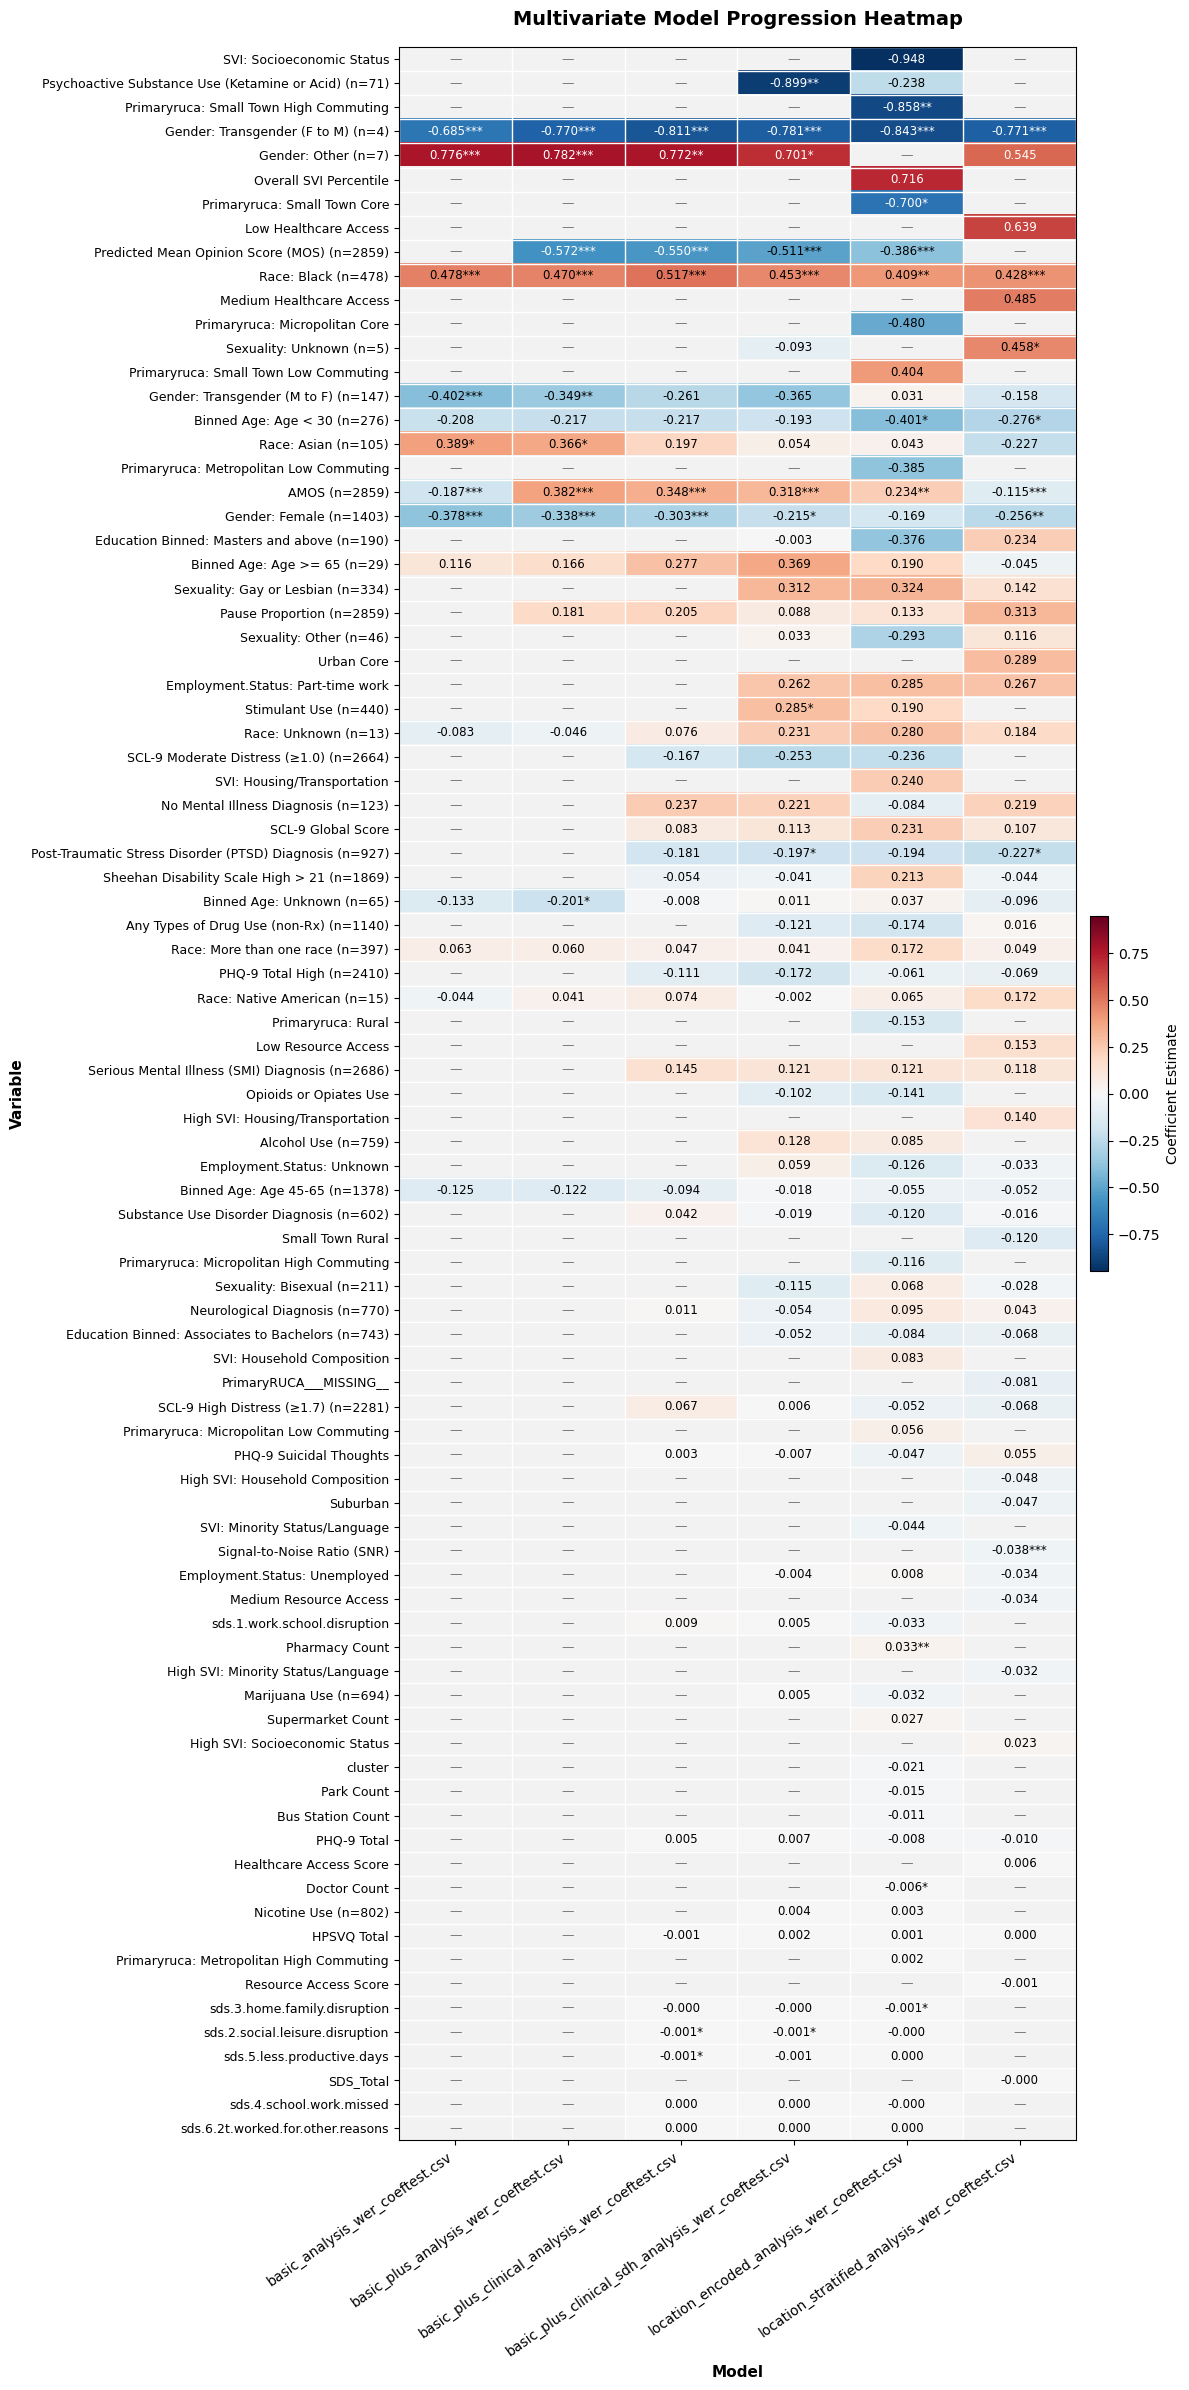

Saved visualization to: /edata/obdw/sandwich_analysis_data/multivariate_model_progression_heatmap.png


In [13]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

use_full_table = False
table_path = full_output if use_full_table else presentation_output
plot_title = 'Multivariate Model Progression Heatmap (Full Table)' if use_full_table else 'Multivariate Model Progression Heatmap'
plot_output = DATA_DIR / ('multivariate_model_progression_heatmap_full.png' if use_full_table else 'multivariate_model_progression_heatmap.png')

plot_df = pd.read_csv(table_path)
model_columns = [model_file.name for model_file in MODEL_FILES]
available_model_columns = [col for col in model_columns if col in plot_df.columns]

if not available_model_columns:
    raise ValueError('No model columns were found in the selected progression table.')

def parse_estimate(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text in {'', '—'}:
        return np.nan
    match = re.match(r'^([-+]?[0-9]*\.?[0-9]+)', text)
    return float(match.group(1)) if match else np.nan

heatmap_values = plot_df[available_model_columns].apply(lambda column: column.map(parse_estimate))
annotation_values = plot_df[available_model_columns].fillna('—').astype(str)

if 'Count' in plot_df.columns:
    row_labels = [f"{variable} (n={int(count)})" if pd.notna(count) else str(variable) for variable, count in zip(plot_df['Variable'], plot_df['Count'])]
else:
    row_labels = plot_df['Variable'].astype(str).tolist()

valid_rows = heatmap_values.notna().any(axis=1)
heatmap_values = heatmap_values.loc[valid_rows].reset_index(drop=True)
annotation_values = annotation_values.loc[valid_rows].reset_index(drop=True)
row_labels = [label for label, keep in zip(row_labels, valid_rows) if keep]

sort_key = heatmap_values.abs().max(axis=1).fillna(-np.inf)
sort_order = sort_key.sort_values(ascending=False).index
heatmap_values = heatmap_values.loc[sort_order].reset_index(drop=True)
annotation_values = annotation_values.loc[sort_order].reset_index(drop=True)
row_labels = [row_labels[idx] for idx in sort_order]

fig_height = max(8, min(24, 0.42 * len(row_labels)))
fig_width = max(12, 2.0 * len(available_model_columns))
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

masked_values = np.ma.masked_invalid(heatmap_values.to_numpy(dtype=float))
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color='#f2f2f2')

max_abs = np.nanmax(np.abs(masked_values)) if masked_values.count() > 0 else 1.0
if not np.isfinite(max_abs) or max_abs == 0:
    max_abs = 1.0

image = ax.imshow(masked_values, aspect='auto', cmap=cmap, vmin=-max_abs, vmax=max_abs)

ax.set_xticks(np.arange(len(available_model_columns)))
ax.set_xticklabels(available_model_columns, rotation=35, ha='right', fontsize=10)
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_title(plot_title, fontsize=14, fontweight='bold', pad=16)

for row_idx in range(len(row_labels)):
    for col_idx in range(len(available_model_columns)):
        label = annotation_values.iloc[row_idx, col_idx]
        numeric_value = heatmap_values.iloc[row_idx, col_idx]
        if pd.isna(numeric_value):
            ax.text(col_idx, row_idx, '—', ha='center', va='center', fontsize=9, color='#7a7a7a')
        else:
            text_color = 'white' if abs(numeric_value) > 0.55 * max_abs else 'black'
            ax.text(col_idx, row_idx, label, ha='center', va='center', fontsize=8.5, color=text_color)

colorbar = fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
colorbar.set_label('Coefficient Estimate', rotation=90)

ax.set_xlabel('Model', fontsize=11, fontweight='bold')
ax.set_ylabel('Variable', fontsize=11, fontweight='bold')
ax.set_xticks(np.arange(-0.5, len(available_model_columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1)
ax.tick_params(which='minor', bottom=False, left=False)

plt.tight_layout()
plt.savefig(plot_output, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved visualization to: {plot_output}')